# 实验十六：基于 DCT 的图像编码与压缩

## 一、实验目的
- 拆解 JPEG 压缩标准核心流程，理解空间与视觉冗余的消除。
- 理解为什么 JPEG 要做“分块-DCT-量化-重建”。

## 二、实验内容
1. 将图像划分为 $8\times 8$ 分块，独立进行二维离散余弦变换（DCT）。
2. 应用标准量化矩阵进行系数截断。
3. 逆量化与逆 DCT 重建图像，计算压缩比与 PSNR，观察方块效应与振铃效应。

---
本案例是教学实验，包含必要中间结果展示与可视化。

## 三、知识点导入：什么是 DCT 图像压缩？

DCT（离散余弦变换）可以把图像从空间域（像素灰度）变换到频率域（不同频率分量）：

- 低频分量（靠近左上角）通常承载主要轮廓与亮度信息；
- 高频分量（右下角）更多对应细节、纹理和噪声。

JPEG 的核心思想：
1. **分块**：按 $8\times 8$ 切块，降低计算复杂度并匹配局部平稳性；
2. **变换**：每块做 DCT，让能量集中到少量低频系数；
3. **量化**：高频系数更强烈量化（甚至变为 0），实现有损压缩；
4. **编码**：利用零值增多进行熵编码（本实验不展开熵编码细节）。

> 注意：量化越强，压缩越高，但失真也越明显，常见现象包括方块效应和振铃效应。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)

# 标准 JPEG 亮度量化表（Q=50 基准）
Q50 = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99]
], dtype=np.float64)


def dct_matrix(n=8):
    """构造正交 DCT-II 变换矩阵 C，使得 D = C @ X @ C.T"""
    C = np.zeros((n, n), dtype=np.float64)
    factor = np.pi / (2 * n)
    for k in range(n):
        alpha = np.sqrt(1 / n) if k == 0 else np.sqrt(2 / n)
        for i in range(n):
            C[k, i] = alpha * np.cos((2 * i + 1) * k * factor)
    return C


C8 = dct_matrix(8)


def block_view(img, block=8):
    h, w = img.shape
    assert h % block == 0 and w % block == 0, "图像高宽必须是 8 的整数倍"
    return img.reshape(h // block, block, w // block, block).swapaxes(1, 2)


def merge_blocks(blocks):
    bh, bw, b, _ = blocks.shape
    return blocks.swapaxes(1, 2).reshape(bh * b, bw * b)


def dct2_block(block):
    return C8 @ block @ C8.T


def idct2_block(coeff):
    return C8.T @ coeff @ C8


def quality_scale_matrix(Q=50, base=Q50):
    """按 JPEG 常见方式由质量因子生成量化表（1~100）"""
    Q = int(np.clip(Q, 1, 100))
    if Q < 50:
        S = 5000 / Q
    else:
        S = 200 - 2 * Q
    M = np.floor((S * base + 50) / 100)
    M[M < 1] = 1
    M[M > 255] = 255
    return M.astype(np.float64)


def psnr(img_ref, img_test):
    mse = np.mean((img_ref - img_test) ** 2)
    if mse == 0:
        return np.inf
    return 10 * np.log10((255.0 ** 2) / mse)

print('基础函数已就绪。')

基础函数已就绪。


## 四、实验素材准备

为了便于观察压缩伪影，这里先生成一张包含平滑区、边缘和纹理的灰度实验图。你也可以替换为自己的图像。

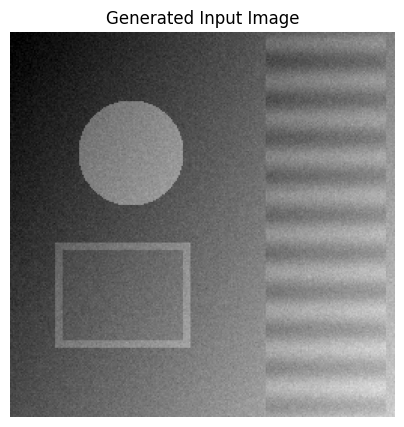

素材图已保存：dct_input.png，尺寸： (256, 256)


In [2]:
# 生成 256x256 灰度实验图（平滑渐变 + 几何结构 + 纹理）
H, W = 256, 256
y, x = np.mgrid[0:H, 0:W]

# 背景渐变
img = 0.5 * x + 0.3 * y

# 加入圆形区域
circle = ((x - 80)**2 + (y - 80)**2) < 35**2
img[circle] += 70

# 加入矩形边缘
img[140:210, 30:120] += 40
img[145:205, 35:115] -= 30

# 加入条纹纹理（高频）
img[:, 170:250] += 20 * np.sin(np.linspace(0, 20 * np.pi, H))[:, None]

# 加入轻微噪声
img += np.random.normal(0, 6, size=(H, W))

img = np.clip(img, 0, 255).astype(np.float64)

# 存为素材图
Image.fromarray(img.astype(np.uint8)).save('dct_input.png')

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Generated Input Image')
plt.axis('off')
plt.show()

print('素材图已保存：dct_input.png，尺寸：', img.shape)

## 五、Step 1：$8\times8$ 分块并进行二维 DCT

流程：
- 先做电平平移：像素减去 128（与 JPEG 一致）；
- 对每个 $8\times8$ 块独立进行二维 DCT；
- 观察一个样本块的空间域与频域系数分布。

分块形状: (32, 32, 8, 8)
样本块（空间域，减128后）:
 [[12.   2.2 10.6  7.7 20.1  7.2 13.2  9.6]
 [14.7 11.8 17.5 14.8  5.9  9.2  4.1  8.4]
 [14.8  8.2 17.1 15.4  9.1 11.1 18.7  4.4]
 [-7.2  1.8 18.7  6.5 13.6 -3.3  3.9  2.3]
 [ 7.9 16.8 10.3  8.1 10.1  2.4 12.  -1.3]
 [10.6 -3.7  2.2  8.1 10.4 15.2 10.8 11.3]
 [11.9  8.1 18.5  5.2  4.6  6.7 13.9  6.7]
 [ 5.4 11.6  4.7  6.  20.1 18.  -8.7 18.5]]
样本块 DCT 系数:
 [[ 73.3   2.6  -8.6  -1.7   0.6   0.8   4.3  10.1]
 [  5.1   5.   -2.9  -3.5  -0.8  11.   -4.    6. ]
 [  9.   -3.1   4.6   5.8   8.8  -9.5   9.2  -4.8]
 [ -2.3  -4.9   5.3   7.7   1.8   7.   -3.6   3.6]
 [ -8.1  -1.4  -8.2  -2.3   3.9 -16.2  -5.3   5. ]
 [ -4.4  -5.3  -2.3  -5.   -3.6   7.3  -0.3  12.9]
 [  4.  -12.2  -1.1  11.5   7.9   0.2   1.9  -2.7]
 [  9.4   8.    5.9   3.5  -8.2   7.   -8.5   1.5]]


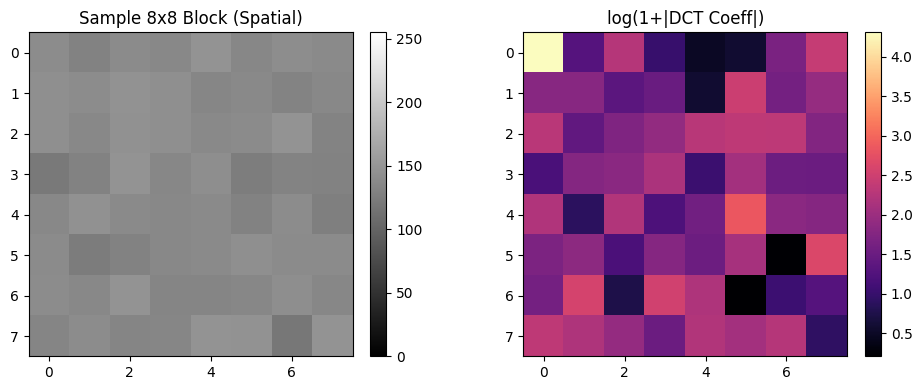

In [3]:
# 电平平移
img_shift = img - 128.0

# 分块并 DCT
blocks = block_view(img_shift, 8)  # (bh, bw, 8, 8)
bh, bw, _, _ = blocks.shape

dct_blocks = np.empty_like(blocks)
for i in range(bh):
    for j in range(bw):
        dct_blocks[i, j] = dct2_block(blocks[i, j])

# 展示一个样本块
sample_i, sample_j = 10, 10
spatial_block = blocks[sample_i, sample_j]
freq_block = dct_blocks[sample_i, sample_j]

print('分块形状:', blocks.shape)
print('样本块（空间域，减128后）:\n', np.round(spatial_block, 1))
print('样本块 DCT 系数:\n', np.round(freq_block, 1))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(spatial_block + 128, cmap='gray', vmin=0, vmax=255)
plt.title('Sample 8x8 Block (Spatial)')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(np.log1p(np.abs(freq_block)), cmap='magma')
plt.title('log(1+|DCT Coeff|)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 六、Step 2：应用标准量化矩阵进行系数截断

这里采用 JPEG 亮度量化思想：
- 质量因子 `QF` 越低，量化步长越大，更多系数变为 0；
- 系数稀疏性提高，压缩潜力更高，但失真更明显。

QF=50, 非零系数: 6331/65536, 零系数占比: 90.34%
估计压缩比(教学近似): 3.88:1
样本块量化后系数:
 [[ 5  0 -1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]


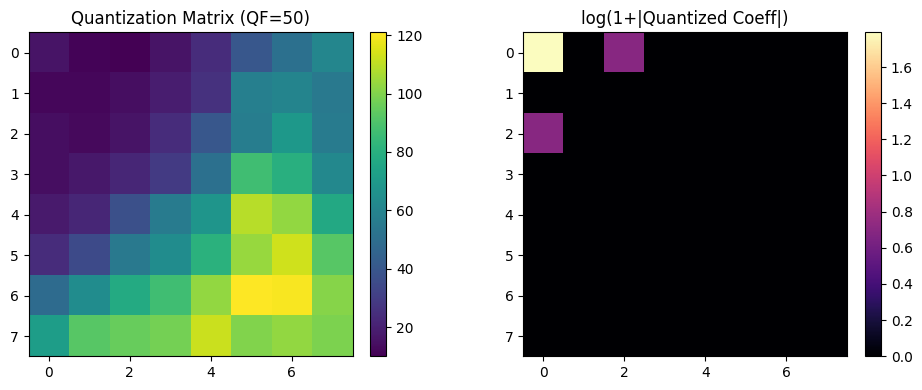

In [4]:
QF_demo = 50
Qmat = quality_scale_matrix(QF_demo)

quant_blocks = np.round(dct_blocks / Qmat[None, None, :, :])
nonzero = np.count_nonzero(quant_blocks)
total = quant_blocks.size
zero_ratio = 1 - nonzero / total

# 简化压缩比估计：原始每系数按 8bit，保留系数按 12bit（仅用于教学近似）
orig_bits = total * 8
compressed_bits_est = nonzero * 12 + (total - nonzero) * 1  # 0 值记作1bit示意
cr_est = orig_bits / compressed_bits_est

sample_q = quant_blocks[sample_i, sample_j]

print(f'QF={QF_demo}, 非零系数: {nonzero}/{total}, 零系数占比: {zero_ratio:.2%}')
print(f'估计压缩比(教学近似): {cr_est:.2f}:1')
print('样本块量化后系数:\n', sample_q.astype(int))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(Qmat, cmap='viridis')
plt.title(f'Quantization Matrix (QF={QF_demo})')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(np.log1p(np.abs(sample_q)), cmap='magma')
plt.title('log(1+|Quantized Coeff|)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 七、Step 3：逆量化 + 逆 DCT 重建，计算 PSNR 与压缩比

我们比较多个质量因子，观察：
- 指标层面：PSNR、零系数比例、估计压缩比；
- 视觉层面：边缘附近振铃、块边界方块效应。

QF=20 | PSNR= 31.64 dB | 零系数占比=96.57% | 估计压缩比= 5.81:1
QF=50 | PSNR= 32.83 dB | 零系数占比=90.34% | 估计压缩比= 3.88:1
QF=80 | PSNR= 34.38 dB | 零系数占比=76.51% | 估计压缩比= 2.23:1


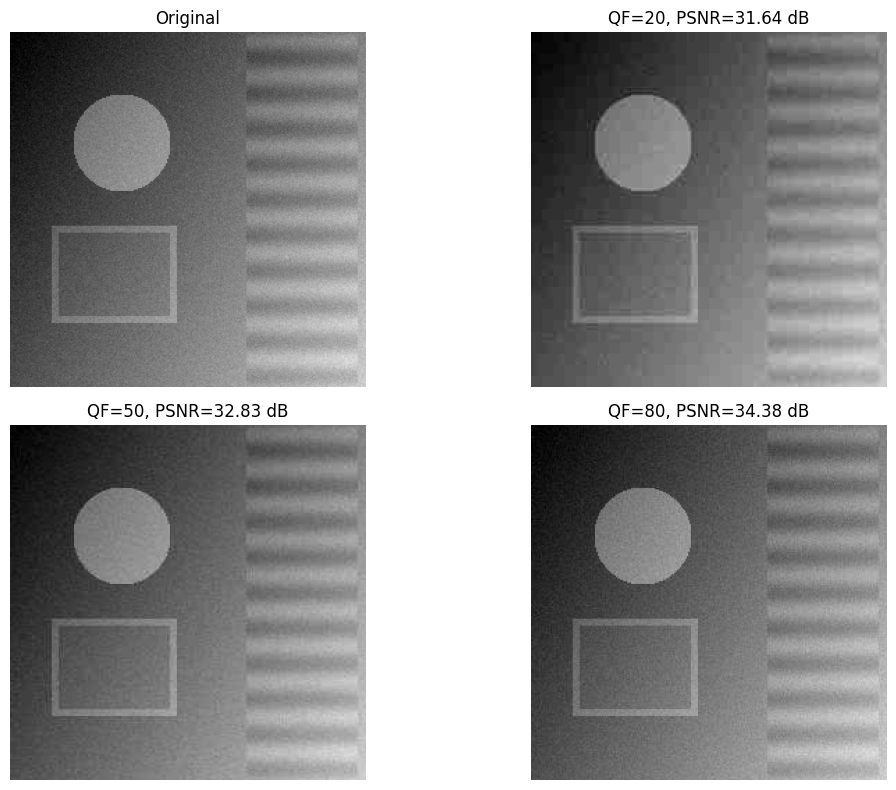

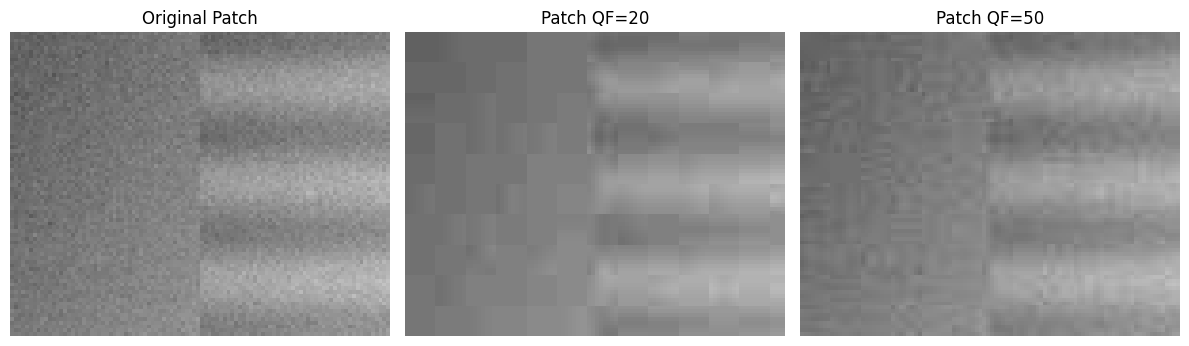

In [5]:
def compress_decompress_by_qf(img_gray, qf):
    img_shift = img_gray - 128.0
    blocks = block_view(img_shift, 8)
    bh, bw, _, _ = blocks.shape

    dct_blocks = np.empty_like(blocks)
    for i in range(bh):
        for j in range(bw):
            dct_blocks[i, j] = dct2_block(blocks[i, j])

    Qm = quality_scale_matrix(qf)
    q_blocks = np.round(dct_blocks / Qm[None, None, :, :])

    # 逆量化 + 逆DCT
    rec_blocks = np.empty_like(blocks)
    for i in range(bh):
        for j in range(bw):
            rec_blocks[i, j] = idct2_block(q_blocks[i, j] * Qm)

    rec_img = np.clip(merge_blocks(rec_blocks) + 128.0, 0, 255)

    nonzero = np.count_nonzero(q_blocks)
    total = q_blocks.size
    zero_ratio = 1 - nonzero / total
    cr_est = (total * 8) / (nonzero * 12 + (total - nonzero) * 1)
    p = psnr(img_gray, rec_img)

    return rec_img, p, zero_ratio, cr_est, q_blocks

qf_list = [20, 50, 80]
results = {}
for qf in qf_list:
    rec, p, zr, cr, qblk = compress_decompress_by_qf(img, qf)
    results[qf] = dict(rec=rec, psnr=p, zero_ratio=zr, cr=cr, qblk=qblk)
    print(f'QF={qf:>2} | PSNR={p:6.2f} dB | 零系数占比={zr:6.2%} | 估计压缩比={cr:5.2f}:1')

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

for k, qf in enumerate(qf_list, start=2):
    plt.subplot(2, 2, k)
    plt.imshow(results[qf]['rec'], cmap='gray', vmin=0, vmax=255)
    plt.title(f"QF={qf}, PSNR={results[qf]['psnr']:.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 局部放大观察方块效应与振铃效应
r0, r1, c0, c1 = 120, 200, 120, 220
plt.figure(figsize=(12, 4))
for idx, qf in enumerate([None, 20, 50], start=1):
    plt.subplot(1, 3, idx)
    if qf is None:
        patch = img[r0:r1, c0:c1]
        title = 'Original Patch'
    else:
        patch = results[qf]['rec'][r0:r1, c0:c1]
        title = f'Patch QF={qf}'
    plt.imshow(patch, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 八、案例应用模块：给定一张图片，使用 DCT 压缩处理

将下方 `input_path` 改为你的图片路径（建议灰度图或可转灰度）。
本模块会输出：
- 原图与重建图
- 指标（PSNR、零系数比例、估计压缩比）
- 残差图（观察失真分布）

输入尺寸: (256, 256), QF=40
PSNR=32.50 dB, 零系数占比=92.73%, 估计压缩比=4.44:1


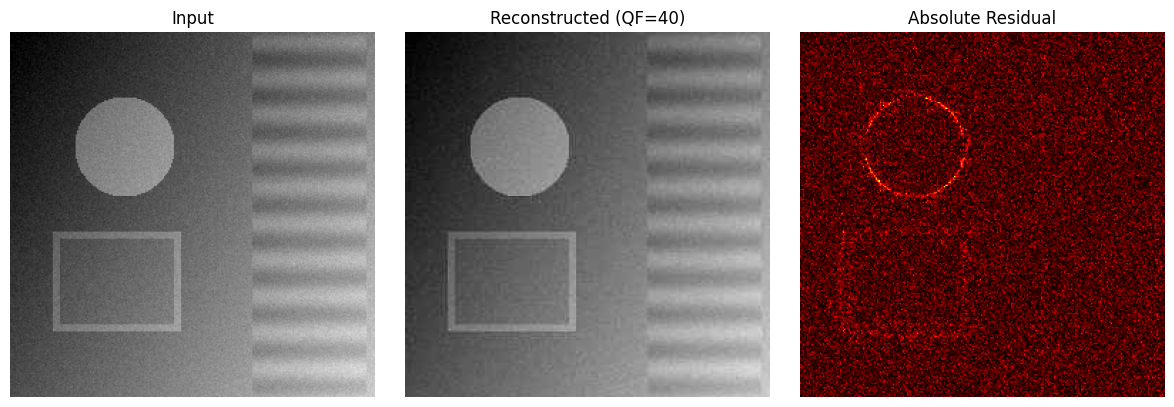

重建结果已保存：dct_reconstructed_case.png


In [6]:
# ===== 案例应用：处理一张给定图片 =====
input_path = 'dct_input.png'   # 改成你的图片路径，例如 'lena.png'
qf_case = 40

img_case = Image.open(input_path).convert('L')
img_case = np.array(img_case, dtype=np.float64)

# 为满足 8x8 分块，必要时裁剪到 8 的整数倍
h, w = img_case.shape
h8, w8 = (h // 8) * 8, (w // 8) * 8
img_case = img_case[:h8, :w8]

rec_case, psnr_case, zr_case, cr_case, _ = compress_decompress_by_qf(img_case, qf_case)
residual = img_case - rec_case

print(f'输入尺寸: {img_case.shape}, QF={qf_case}')
print(f'PSNR={psnr_case:.2f} dB, 零系数占比={zr_case:.2%}, 估计压缩比={cr_case:.2f}:1')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_case, cmap='gray', vmin=0, vmax=255)
plt.title('Input')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rec_case, cmap='gray', vmin=0, vmax=255)
plt.title(f'Reconstructed (QF={qf_case})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.abs(residual), cmap='hot')
plt.title('Absolute Residual')
plt.axis('off')
plt.tight_layout()
plt.show()

Image.fromarray(np.clip(rec_case, 0, 255).astype(np.uint8)).save('dct_reconstructed_case.png')
print('重建结果已保存：dct_reconstructed_case.png')

## 九、面向学生的拓展与思考（含解答思路）

### 思考题 1：为什么 JPEG 采用 $8\times8$ 而不是更大或更小分块？
**解答思路：**
- 从计算复杂度、局部平稳性和硬件实现三方面分析；
- 分块太小：频率分辨率不够，压缩潜力下降；
- 分块太大：计算量增大，且局部假设不成立；
- 可设计实验比较 $4\times4, 8\times8, 16\times16$ 的 PSNR 与视觉质量。

### 思考题 2：PSNR 高是否一定主观视觉更好？
**解答思路：**
- PSNR 反映像素级误差，不完全符合人眼感知；
- 可结合结构相似性 SSIM，或观察边缘与纹理区域误差热图；
- 对比“同 PSNR 不同伪影类型”的两幅图，讨论主观质量差异。

### 思考题 3：如何减弱方块效应与振铃效应？
**解答思路：**
- 降低量化强度（提高 QF）；
- 在解码端进行去块滤波（deblocking）；
- 使用更先进变换与预测机制（如 H.264/HEVC 的环路滤波思想）。

### 思考题 4：本实验若补上熵编码，压缩比会如何变化？
**解答思路：**
- 量化后零系数增多，游程编码（RLE）效率提升；
- DC 可差分编码，AC 可按 Zig-Zag 排列后做 RLE + Huffman；
- 可统计零游程分布，估算熵编码增益。

---
## 十、小结
本实验复现了 JPEG 核心链路：**分块 → DCT → 量化 → 逆量化 → IDCT 重建**，并通过 PSNR、零系数比例和可视化结果建立了“压缩率-失真”权衡的直观认识。